In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, curve_fit
from emcee import EnsembleSampler

import matplotlib.pyplot as plt

In [2]:
#read in data, fix columns
df = (pd.read_csv("../data/polarizer_correlation.csv")
      .drop(columns=['Trial Number', 'Angle A'])
      .rename(columns={
          "Angle B": "ANGLE",
          "N_coin / time": "COIN_RATE",
          "TIME [s]": "TIME"
      }))
df['E_N_COIN'] = np.sqrt(df['N_COIN'])
df['E_COIN_RATE'] = df['E_N_COIN'] / df['TIME']
df

,ANGLE,N_A,N_B,N_COIN,TIME,COIN_RATE,E_N_COIN,E_COIN_RATE
0,0.0,NaN,NaN,14340,10.00077,1433.889591,119.749739,11.974052
1,22.5,NaN,NaN,13079,9.99107,1309.068999,114.363456,11.446567
2,30.0,NaN,NaN,11696,9.99126,1170.623125,108.148047,10.824265
3,45.0,NaN,NaN,8637,10.00051,863.655954,92.935461,9.293072
4,60.0,NaN,NaN,5221,9.99106,522.567175,72.256488,7.232114
5,67.5,NaN,NaN,3204,10.00011,320.396476,56.603887,5.660326
6,90.0,NaN,NaN,1333,9.98170,133.544386,36.510273,3.657721
7,100.0,NaN,NaN,1651,9.98067,165.419756,40.632499,4.071119
8,112.5,NaN,NaN,3362,10.00016,336.194621,57.982756,5.798183
9,120.0,NaN,NaN,4630,9.98259,463.807489,68.044103,6.816277


In [3]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15

In [4]:
def model(x, phase, amplitude, baseline):
    x = np.array(x)
    y = amplitude * np.cos(x * np.pi / 90 + phase * np.pi/180) + baseline
    return y

In [5]:
def chi_sq(theta, uncertainty_multiplier = 1):
    y_mod = model(df["ANGLE"], *theta)
    y_data = df["COIN_RATE"]
    return np.sum((y_data - y_mod)**2/(df['E_COIN_RATE'] * uncertainty_multiplier)**2) / len(df - len(theta))

In [6]:
p0 = [0, 750, 750]
pcurve_fit, ecurve_fit = curve_fit(model, df['ANGLE'], df['COIN_RATE'], p0)

7.842911392659538


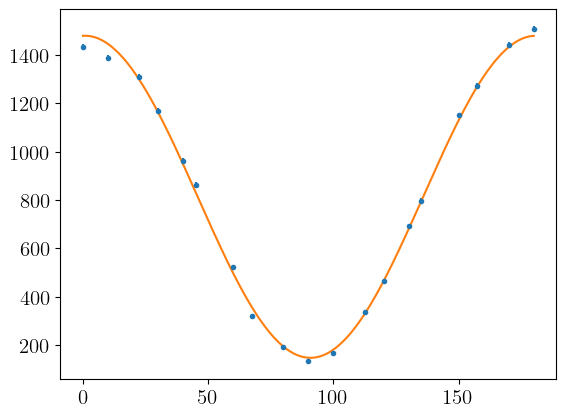

In [7]:
plt.errorbar(df["ANGLE"], df["COIN_RATE"], df['E_COIN_RATE'], ls='', marker='.')
x = np.linspace(0, 180, 1000)
plt.plot(x, model(x, *pcurve_fit))
print(chi_sq(pcurve_fit))

In [8]:
#mcmc prior
def log_prior(theta):
    if np.any(theta[1:] < 0):
        return -np.inf
    return 0

#mcmc log likelihood
def log_prob(theta):
    if log_prior(theta) == -np.inf:
        return -np.inf
    
    y_mod = model(df['ANGLE'], *theta)
    y_real = df['COIN_RATE']
    return np.sum(-(y_mod - y_real)**2/df['E_COIN_RATE']**2)

In [9]:
#initialize mcmc walkers
N_WALKERS = 16
BUMP_SIZE = 1
x0 = pcurve_fit + BUMP_SIZE * np.random.randn(N_WALKERS, len(pcurve_fit))

In [11]:
#run mcmc
# from multiprocessing import Pool, cpu_count

# with Pool(cpu_count()) as p:
sampler = EnsembleSampler(N_WALKERS, x0.shape[1], log_prob)
sampler.run_mcmc(x0, 10000, progress=True)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [01:57<00:00, 85.02it/s]


State([[ -1.56584886 678.32222695 814.30639931]
 [ -1.57952924 674.60388437 815.02893064]
 [ -1.23234041 674.76252525 811.33088999]
 [ -1.34739117 673.38860002 813.62221556]
 [ -1.61935548 673.63327666 813.73819532]
 [ -1.38057068 675.15605493 814.66939818]
 [ -1.37014964 677.38392638 815.67322163]
 [ -1.85401098 673.74901612 814.88287845]
 [ -1.36078331 672.40194105 813.07778272]
 [ -1.36410882 671.04602441 809.30266335]
 [ -1.53875937 674.10585196 812.32921485]
 [ -1.46505473 675.77144955 812.2795802 ]
 [ -1.4622613  673.17988843 813.04168234]
 [ -1.46641905 673.39929107 809.56109643]
 [ -1.33984236 677.87056104 814.84778163]
 [ -1.76155422 671.87260938 811.06908848]], log_prob=[-131.74735094 -131.12943149 -131.2963759  -130.3651494  -130.16475409
 -130.39291023 -131.69277411 -134.07832441 -130.65099696 -132.10916099
 -129.06788075 -129.85353705 -129.55676426 -131.89997937 -131.53954115
 -131.35506244], blobs=None, random_state=('MT19937', array([3680156169, 4117623515, 4261668901, 1

In [25]:
#names of parameters
param_labels = [
    "Phase $[\\mathrm{deg}]$",
    "Amplitude $[\\mathrm{s}^{-1}]$",
    "Baseline $[\\mathrm{s}^{-1}]$"
]

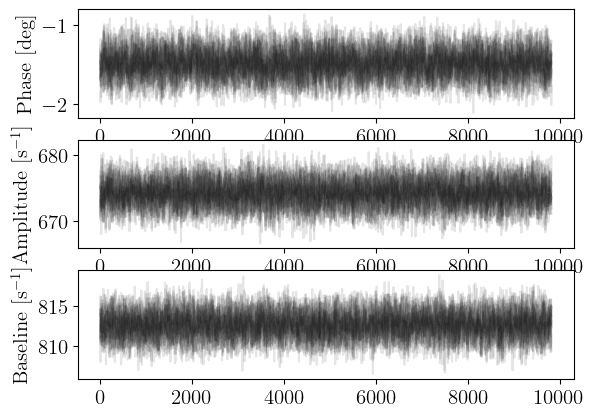

In [27]:
#check fit stability 
autocorr_time = sampler.get_autocorr_time()
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)))
for dim_n in range(chain.shape[2]):
    ax = plt.subplot(chain.shape[2], 1, dim_n + 1)
    ax.set_ylabel(param_labels[dim_n])
    for walker_n in range(chain.shape[1]):
        plt.plot(chain[:, walker_n, dim_n], c='black', alpha=0.1)

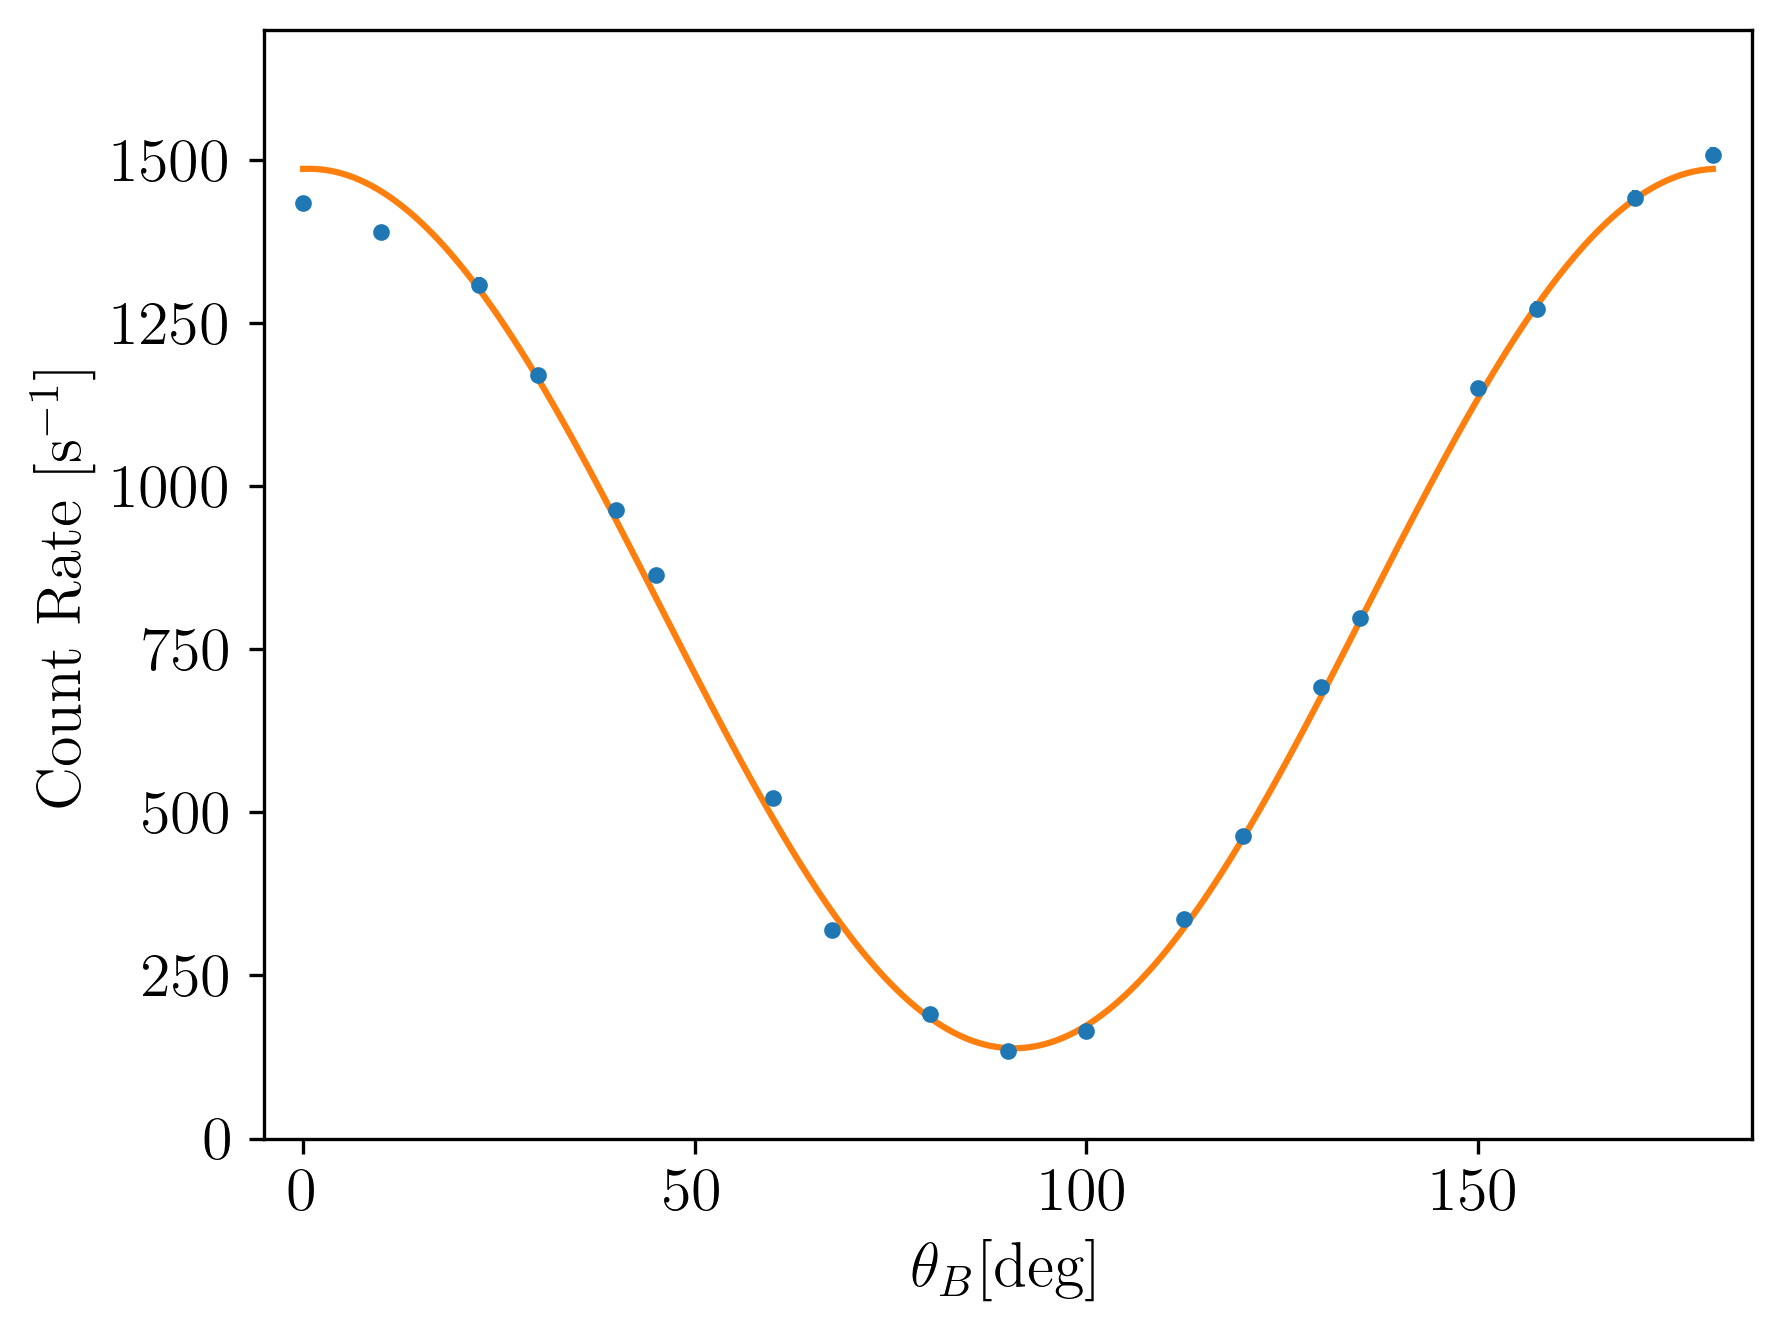

In [28]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, ax = plt.subplots(dpi = 300)

ax.errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"], ls="", marker=".")
x = np.linspace(0, 180, 500)
ax.plot(x, model(x, *np.median(chain, axis = 0)))

ax.set_ylim(0, 1700)
ax.set_xlim(-5, 185)

ax.set_xlabel("$\\theta_B [\\text{deg}]$")
ax.set_ylabel("Count Rate $[\\text{s}^{-1}]$")
plt.savefig("../figures/mcmc_polarizer_fit.png", bbox_inches = "tight")

In [30]:
df

,ANGLE,N_A,N_B,N_COIN,TIME,COIN_RATE,E_N_COIN,E_COIN_RATE
0,0.0,NaN,NaN,14340,10.00077,1433.889591,119.749739,11.974052
1,22.5,NaN,NaN,13079,9.99107,1309.068999,114.363456,11.446567
2,30.0,NaN,NaN,11696,9.99126,1170.623125,108.148047,10.824265
3,45.0,NaN,NaN,8637,10.00051,863.655954,92.935461,9.293072
4,60.0,NaN,NaN,5221,9.99106,522.567175,72.256488,7.232114
5,67.5,NaN,NaN,3204,10.00011,320.396476,56.603887,5.660326
6,90.0,NaN,NaN,1333,9.98170,133.544386,36.510273,3.657721
7,100.0,NaN,NaN,1651,9.98067,165.419756,40.632499,4.071119
8,112.5,NaN,NaN,3362,10.00016,336.194621,57.982756,5.798183
9,120.0,NaN,NaN,4630,9.98259,463.807489,68.044103,6.816277


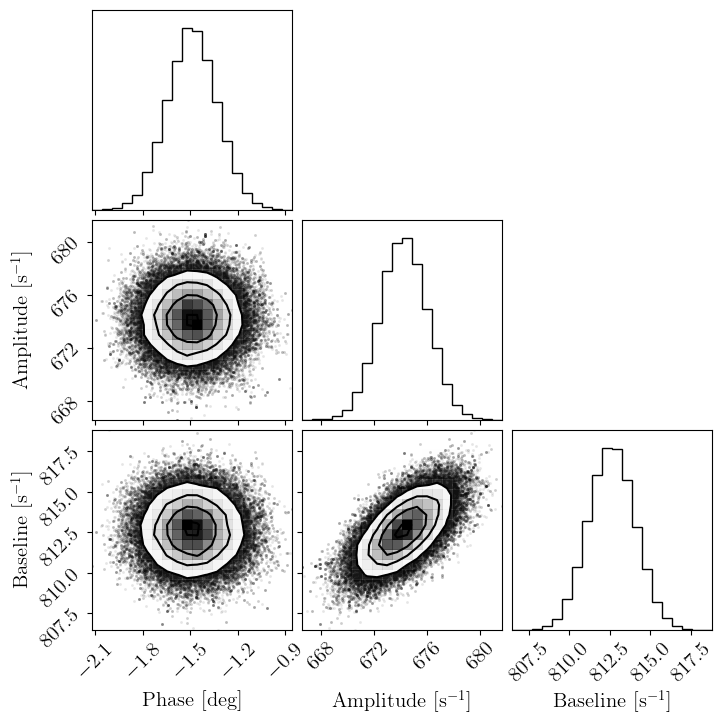

In [37]:
#examine posterior distributions of parameters
import corner
corner.corner(sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True), labels=param_labels).savefig("../figures/crater_plot.png", dpi=800)

In [33]:
chain = sampler.get_chain(flat=True, discard=int(np.max(autocorr_time*4)))
results = pd.DataFrame(
    {
        "Median Value": np.median(chain, axis = 0),
        "Uncertainty": np.sqrt(np.diag(np.cov(chain.T))),
        "2-sigma Uncertainty": np.sqrt(np.diag(np.cov(chain.T))) * 2
    },
    index=param_labels
)
results["Uncertainty/Value"] = results["2-sigma Uncertainty"]/results["Median Value"]

In [63]:

results.to_csv("../data/mcmc_fit.csv")
results

,Median Value,Uncertainty,2-sigma Uncertainty,Uncertainty/Value
Phase $[\mathrm{deg}]$,-1.504512,0.414109,0.828218,-0.550490
Amplitude $[\mathrm{s}^{-1}]$,674.204581,4.718881,9.437761,0.013998
Baseline $[\mathrm{s}^{-1}]$,812.440739,3.743053,7.486105,0.009214


In [38]:
chi_sq_mcmc = chi_sq(np.median(chain, axis = 0))
chi_sq_mcmc
#quite high, will try rescaling errors 

np.float64(6.78946493800067)

In [39]:
#mcmc log likelihood
def log_prob_adjusted(theta):
    if log_prior(theta) == -np.inf:
        return -np.inf
    
    y_mod = model(df['ANGLE'], *theta)
    y_real = df['COIN_RATE']
    return np.sum(-(y_mod - y_real)**2/(df['E_COIN_RATE'] * np.sqrt(chi_sq_mcmc))**2)

In [40]:
#initialize mcmc walkers
N_WALKERS = 16
BUMP_SIZE = 1
x0 = pcurve_fit + BUMP_SIZE * np.random.randn(N_WALKERS, len(pcurve_fit))

In [41]:
#run mcmc
sampler = EnsembleSampler(N_WALKERS, x0.shape[1], log_prob_adjusted)
sampler.run_mcmc(x0, 10000, progress=True)

100%|██████████| 10000/10000 [02:15<00:00, 73.55it/s]


State([[ -1.62650337 669.37959767 810.48280792]
 [ -1.52675067 680.35881682 814.52718506]
 [ -1.63463706 677.59045626 817.72783363]
 [ -1.99584693 675.70048225 809.75583327]
 [ -2.17706893 681.17013054 815.11897693]
 [ -2.3205907  670.08487347 809.46138178]
 [ -1.76166593 661.40450075 808.30524764]
 [ -1.92236857 659.87058648 805.57663889]
 [ -1.18787424 677.98244632 814.79989049]
 [ -1.84399038 680.36209991 815.33100936]
 [ -1.76162341 672.04451739 817.61329165]
 [ -1.36318104 670.60803955 812.44888181]
 [ -1.54886858 667.69576031 805.30805674]
 [ -1.48736593 680.5053151  810.36667644]
 [ -2.08387897 667.71124062 808.22993871]
 [ -1.34619857 675.89574597 816.44173481]], log_prob=[-19.59413205 -19.93444299 -20.00547517 -20.57891931 -21.58666936
 -21.45527212 -23.19941851 -24.21022959 -19.58912808 -20.24684175
 -21.4717537  -19.51523735 -20.95550755 -21.58743202 -21.05102588
 -19.65446698], blobs=None, random_state=('MT19937', array([ 190814675, 1805390670,  517559106,  461655999, 40179

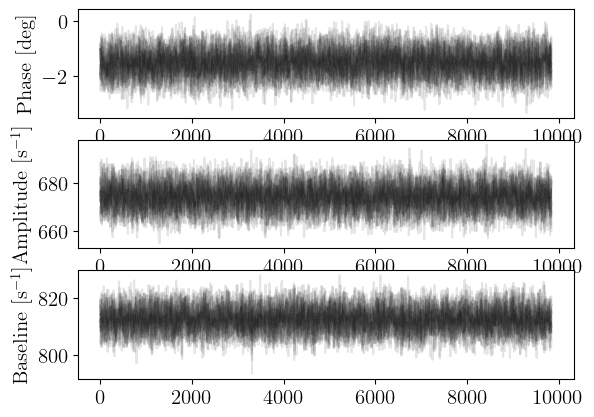

In [42]:
#check fit stability 
autocorr_time = sampler.get_autocorr_time()
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)))
for dim_n in range(chain.shape[2]):
    ax = plt.subplot(chain.shape[2], 1, dim_n + 1)
    ax.set_ylabel(param_labels[dim_n])
    for walker_n in range(chain.shape[1]):
        plt.plot(chain[:, walker_n, dim_n], c='black', alpha=0.1)

1.0001096707875035


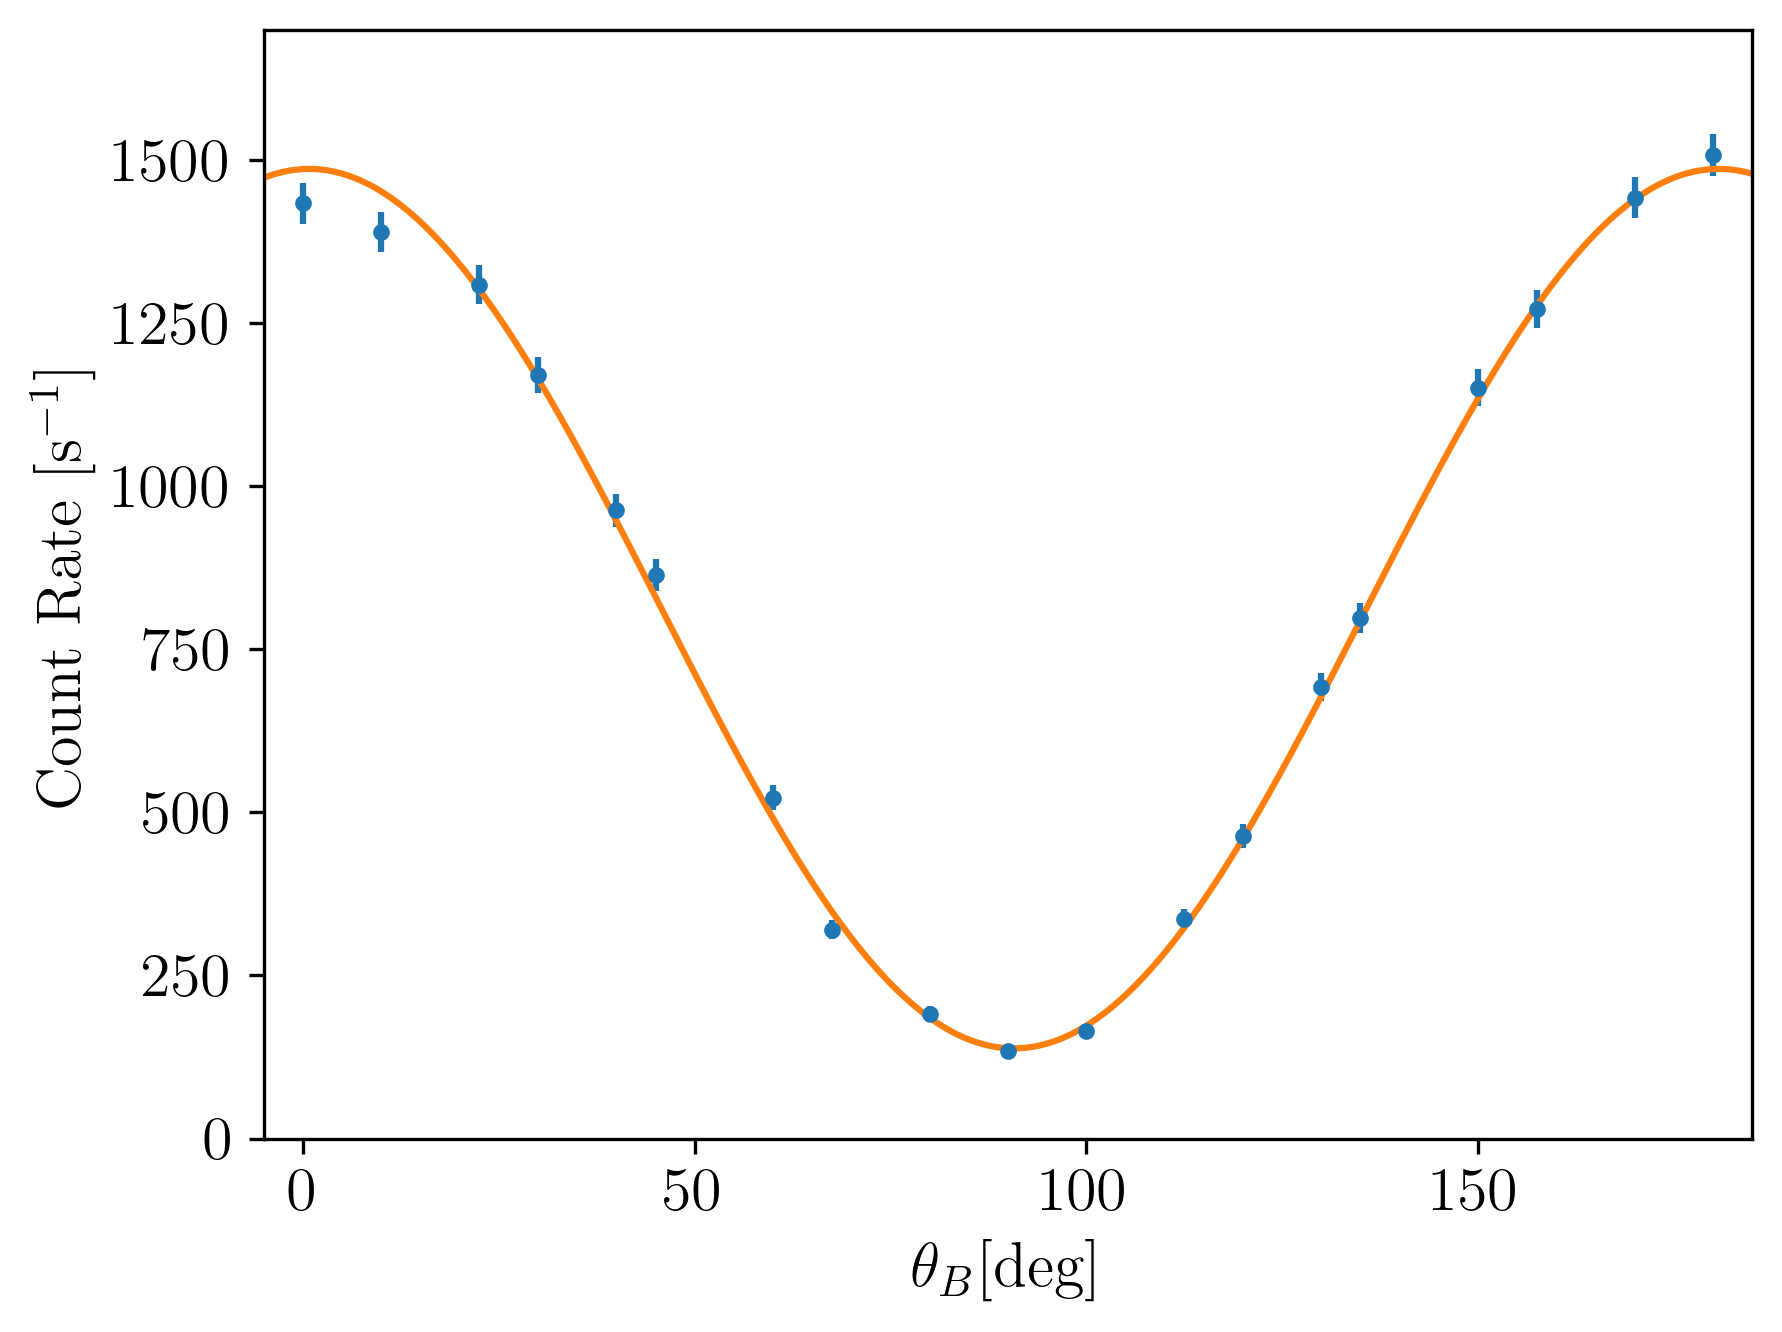

In [45]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, ax = plt.subplots(dpi = 300)

ax.errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"] * np.sqrt(chi_sq_mcmc), ls="", marker=".")
x = np.linspace(-5, 185, 500)
ax.plot(x, model(x, *np.median(chain, axis = 0)))

ax.set_ylim(0, 1700)
ax.set_xlim(-5, 185)
ax.set_xlabel("$\\theta_B [\\text{deg}]$")
ax.set_ylabel("Count Rate $[\\text{s}^{-1}]$")
plt.savefig("../figures/mcmc_polarizer_fit_adjusted_sigma.png", bbox_inches = "tight")
#new chi sq
print(chi_sq(np.median(chain, axis = 0), np.sqrt(chi_sq_mcmc)))

In [46]:
chain = sampler.get_chain(flat=True, discard=int(np.max(autocorr_time*4)))
results = pd.DataFrame(
    {
        "Median Value": np.median(chain, axis = 0),
        "Uncertainty": np.sqrt(np.diag(np.cov(chain.T))),
        "2-sigma Uncertainty": np.sqrt(np.diag(np.cov(chain.T))) * 2
    },
    index=param_labels
)
results["Uncertainty/Value"] = results["2-sigma Uncertainty"]/results["Median Value"]

In [62]:
results.to_csv("../data/mcmc_fit_adjusted.csv")
results

,Median Value,Uncertainty,2-sigma Uncertainty,Uncertainty/Value
Phase $[\mathrm{deg}]$,-1.504512,0.414109,0.828218,-0.550490
Amplitude $[\mathrm{s}^{-1}]$,674.204581,4.718881,9.437761,0.013998
Baseline $[\mathrm{s}^{-1}]$,812.440739,3.743053,7.486105,0.009214


1.0001096707875035


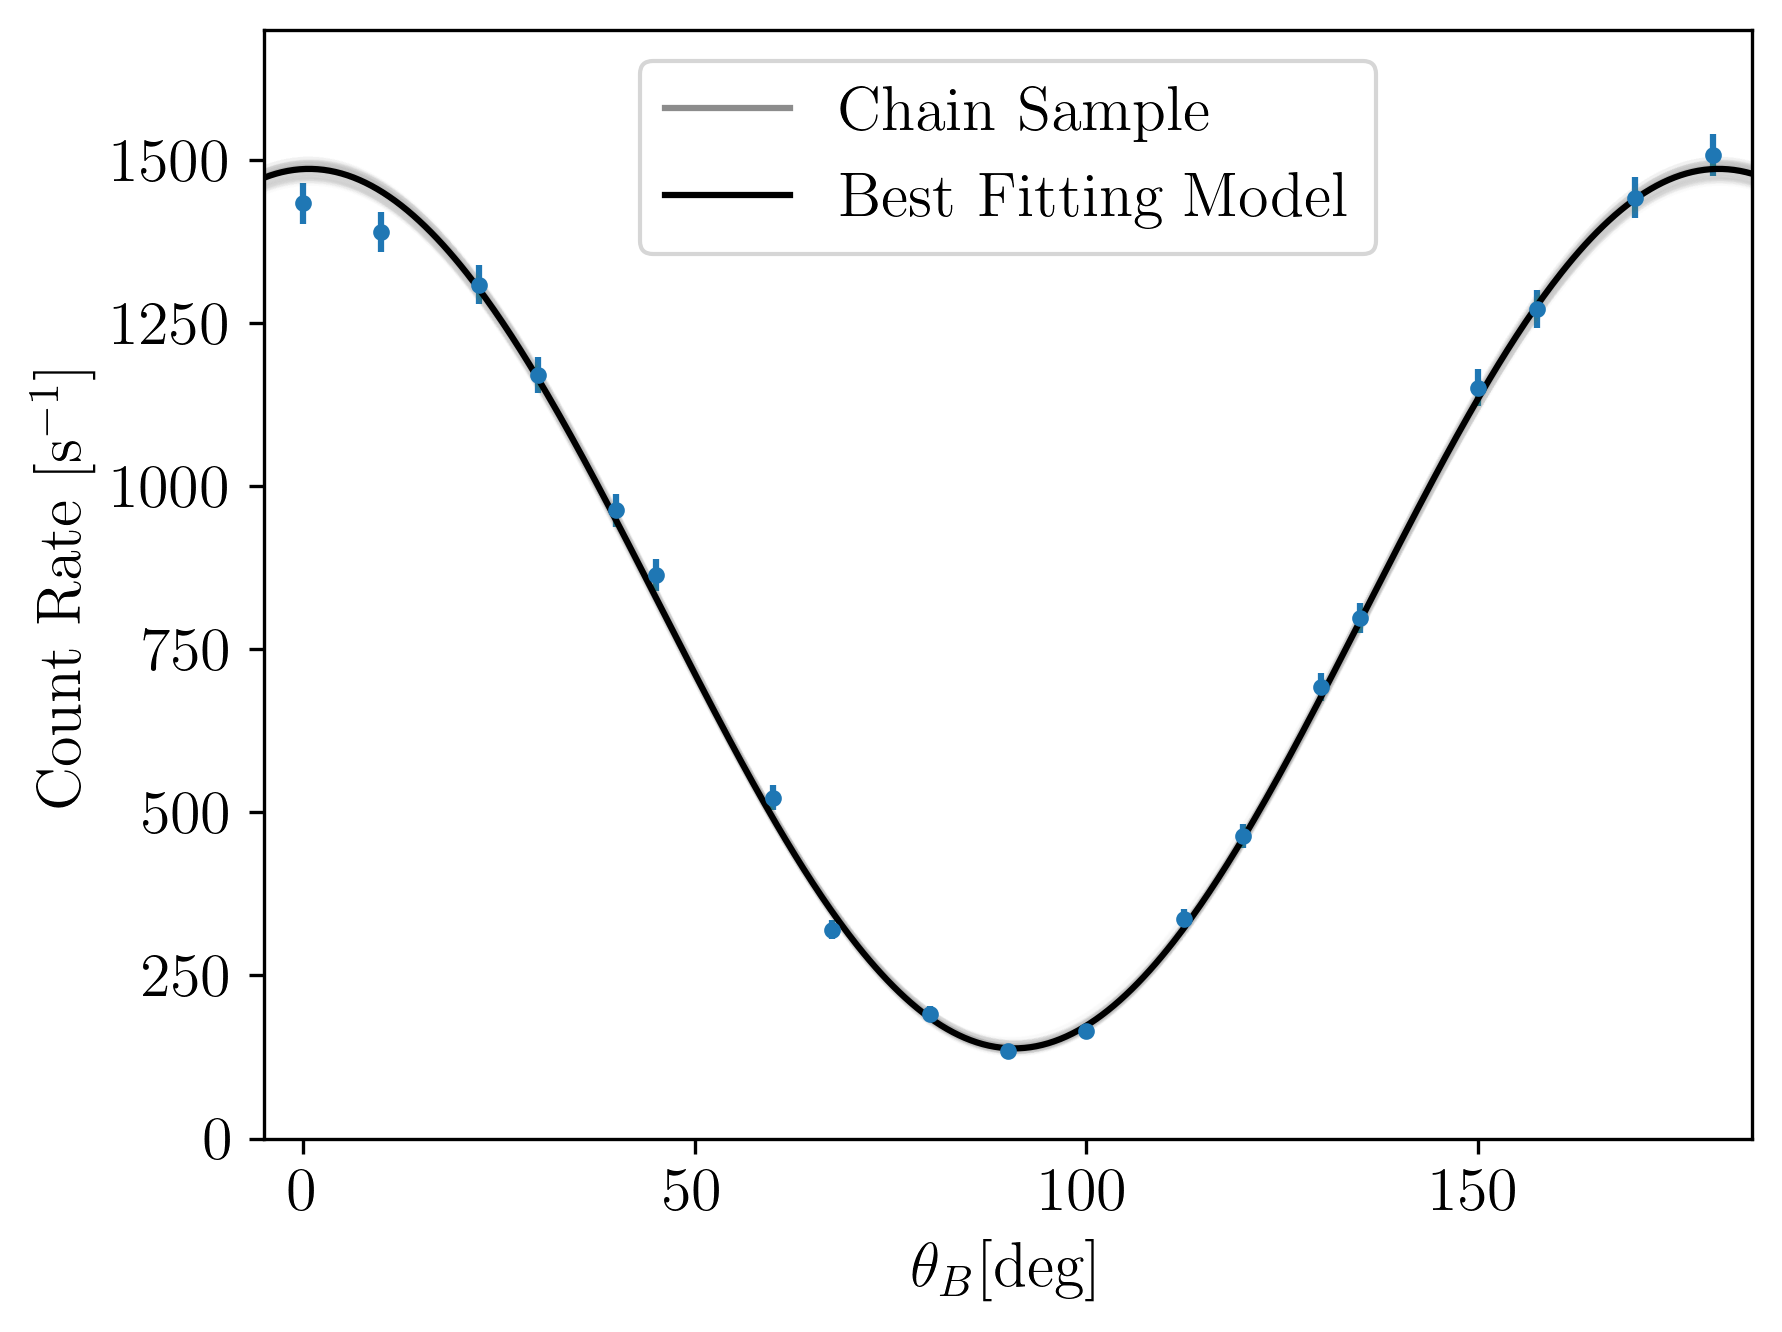

In [61]:
from matplotlib.lines import Line2D

chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, ax = plt.subplots(dpi = 300)

ax.errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"] * np.sqrt(chi_sq_mcmc), ls="", marker=".")
x = np.linspace(-5, 185, 500)
for i in range(100):
    ax.plot(x, model(x, *chain[-i]), color = "gray", alpha = 0.01)
ax.plot(x, model(x, *np.median(chain, axis = 0)), color = "black")
ax.set_ylim(0, 1700)
ax.set_xlim(-5, 185)
ax.set_xlabel("$\\theta_B [\\text{deg}]$")
ax.set_ylabel("Count Rate $[\\text{s}^{-1}]$")

legend_handles = [
    Line2D([0], [0], color="gray", alpha=0.9, lw=1.5, label="Chain Sample"),
    Line2D([0], [0], color="black", lw=1.5, label="Best Fitting Model")
]
ax.legend(handles=legend_handles)

plt.savefig("../figures/density_plot.png", bbox_inches = "tight")
#new chi sq
print(chi_sq(np.median(chain, axis = 0), np.sqrt(chi_sq_mcmc)))

In [ ]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, axs = plt.subplots(2, dpi = 300, height_ratios = [5, 1], sharex = True)

axs[0].errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"] * np.sqrt(chi_sq_mcmc), ls="", marker=".")
x = np.linspace(-5, 185, 500)
#ax.plot(x, model(x, *np.median(chain, axis = 0)))
for i in range(100):
    axs[0].plot(x, model(x, *chain[-i]), color = "black", alpha = 0.01)
axs[0].set_ylim(0, 1700)
axs[0].set_xlim(-5, 185)
axs[1].set_xlabel("$\\theta_B [\\deg]$")
axs[0].set_ylabel("Count Rate $[\\text{s}^{-1}]$")
plt.subplots_adjust(hspace=.1)

axs[1].set_xticks(np.linspace(0, 180, 5))
axs[1].set_xticks(np.linspace(22.5, 157.5, 4), minor=True)
axs[1].set_ylabel("Resid.")
axs[1].set_yticks([-75, 0, 75])
axs[1].set_ylim([-100,100])
axs[1].axhline(0, color = "black")
axs[1].errorbar(df['ANGLE'], df['COIN_RATE'] - model(df["ANGLE"], *np.median(chain, axis = 0)), df["E_COIN_RATE"] * np.sqrt(chi_sq_mcmc), ls="", marker=".")
plt.savefig("figures/residual_plot.png", bbox_inches = "tight")